In [ ]:
!pip install -q timm seaborn

In [ ]:
import os
import zipfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import timm

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

ZIP_PATH = "/content/DRdataset.zip"
EXTRACT_PATH = "/content/data"

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 10
LR = 1e-4
N_SPLITS = 5
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [ ]:
with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("ZIP extracted successfully")

ZIP extracted successfully


In [ ]:
items = os.listdir(EXTRACT_PATH)

if len(items) == 1 and os.path.isdir(os.path.join(EXTRACT_PATH, items[0])):
    DATASET_PATH = os.path.join(EXTRACT_PATH, items[0])
else:
    DATASET_PATH = EXTRACT_PATH

print("Dataset Path:", DATASET_PATH)

Dataset Path: /content/data


In [ ]:
class_names = sorted([
    x for x in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, x))
])

print("Detected Classes:", class_names)

Detected Classes: ['DR', 'No_DR']


In [ ]:
data = []

for label, class_name in enumerate(class_names):

    class_path = os.path.join(DATASET_PATH, class_name)

    for file in os.listdir(class_path):

        if file.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp")
        ):
            full_path = os.path.join(class_path, file)
            data.append([full_path, label, class_name])

df = pd.DataFrame(
    data,
    columns=["image_path", "label", "class_name"]
)

print("Total Images:", len(df))
print(df.head())

Total Images: 2838
                                          image_path  label class_name
0  /content/data/DR/7bc4dd99eee5_png.rf.a78968937...      0         DR
1  /content/data/DR/3f8d5c940ba4_png.rf.613502084...      0         DR
2  /content/data/DR/ca7570c5925c_png.rf.446d01cbc...      0         DR
3  /content/data/DR/46923eea9a4e_png.rf.04d6018a6...      0         DR
4  /content/data/DR/ca360bec5851_png.rf.2bafd4dac...      0         DR


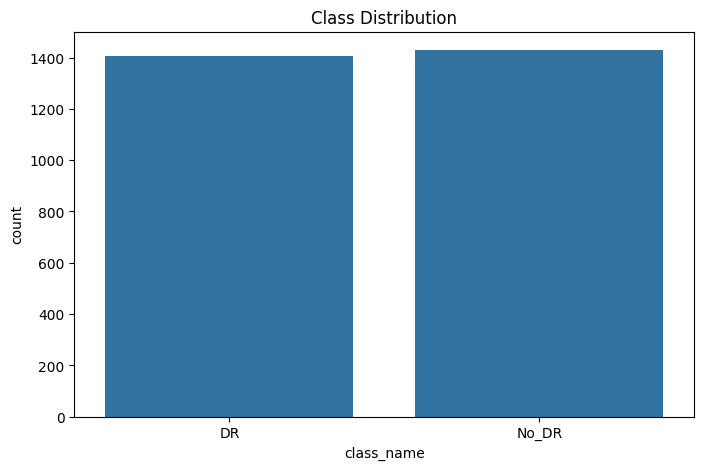

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="class_name")
plt.title("Class Distribution")
plt.show()

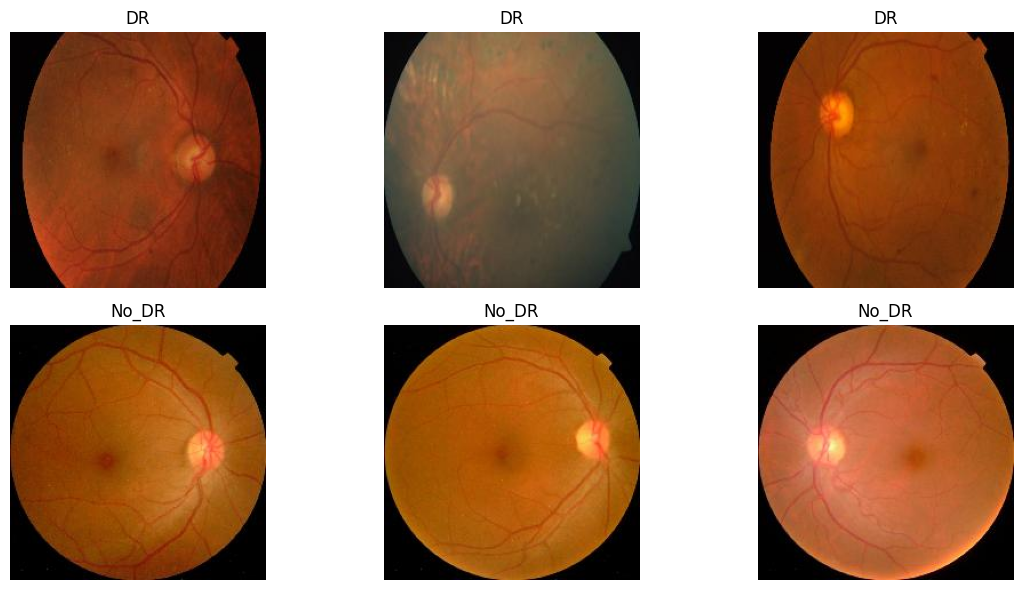

In [ ]:
plt.figure(figsize=(12,6))

for i, cls in enumerate(class_names):

    samples = df[df["class_name"] == cls].sample(
        3,
        random_state=SEED
    )["image_path"].values

    for j in range(3):

        img = Image.open(samples[j]).convert("RGB")

        plt.subplot(len(class_names),3,i*3+j+1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

plt.tight_layout()
plt.show()

100%|██████████| 2838/2838 [00:00<00:00, 6760.20it/s]



Average Width : 224.0
Average Height: 224.0
Min Width : 224
Max Width : 224
Min Height: 224
Max Height: 224


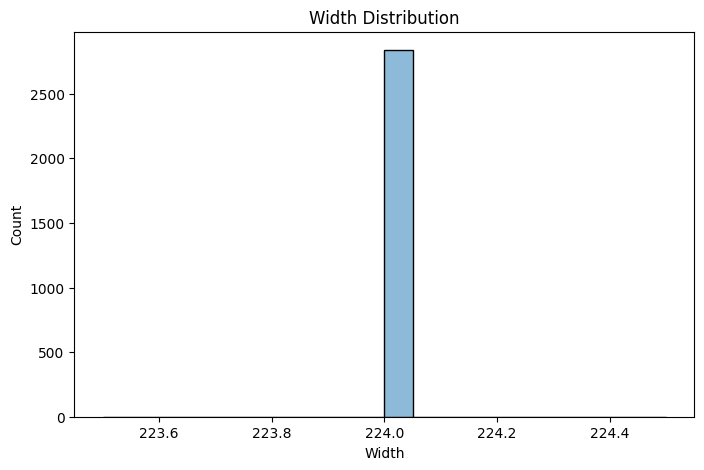

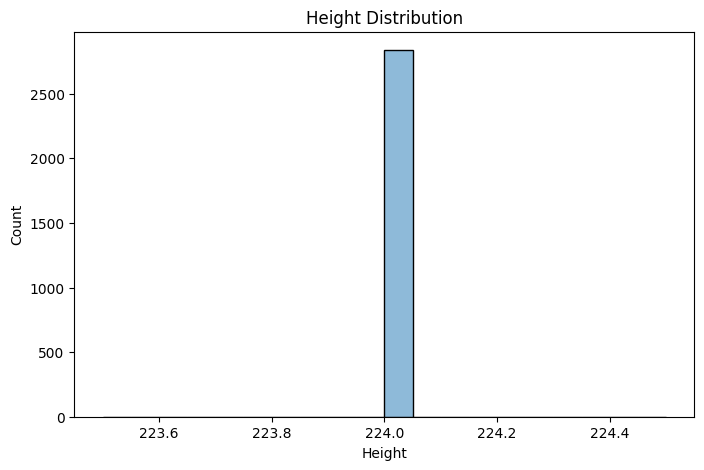


Resolution Count:
resolution
224x224    2838
Name: count, dtype: int64


In [ ]:
widths = []
heights = []

for path in tqdm(df["image_path"]):

    img = Image.open(path)
    w,h = img.size

    widths.append(w)
    heights.append(h)

df["width"] = widths
df["height"] = heights

print("\nAverage Width :", np.mean(widths))
print("Average Height:", np.mean(heights))
print("Min Width :", np.min(widths))
print("Max Width :", np.max(widths))
print("Min Height:", np.min(heights))
print("Max Height:", np.max(heights))


plt.figure(figsize=(8,5))
sns.histplot(widths, bins=20, kde=True)
plt.title("Width Distribution")
plt.xlabel("Width")
plt.show()


plt.figure(figsize=(8,5))
sns.histplot(heights, bins=20, kde=True)
plt.title("Height Distribution")
plt.xlabel("Height")
plt.show()


df["resolution"] = (
    df["width"].astype(str) + "x" +
    df["height"].astype(str)
)

print("\nResolution Count:")
print(df["resolution"].value_counts())

100%|██████████| 200/200 [00:00<00:00, 840.64it/s]



Average Pixel Mean : 0.2404095242263572
Average Pixel Std  : 0.22069893268718377


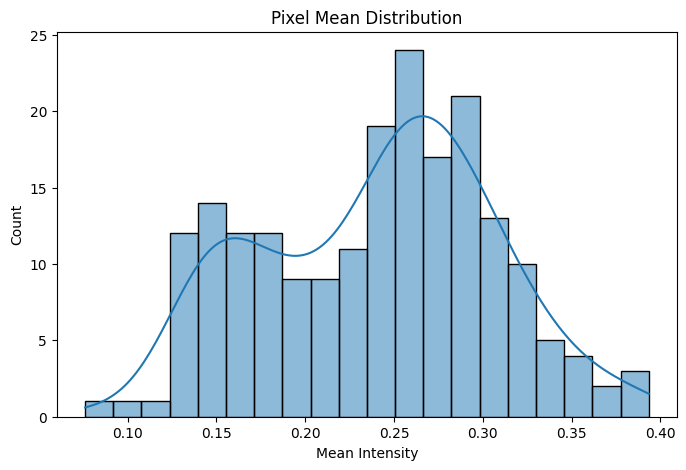

In [ ]:
pixel_means = []
pixel_stds = []

sample_paths = df["image_path"].sample(
    min(200, len(df)),
    random_state=SEED
)

for path in tqdm(sample_paths):

    img = np.array(
        Image.open(path).convert("RGB")
    ) / 255.0

    pixel_means.append(img.mean())
    pixel_stds.append(img.std())

print("\nAverage Pixel Mean :", np.mean(pixel_means))
print("Average Pixel Std  :", np.mean(pixel_stds))

# Histogram Mean Pixel

plt.figure(figsize=(8,5))
sns.histplot(pixel_means, bins=20, kde=True)
plt.title("Pixel Mean Distribution")
plt.xlabel("Mean Intensity")
plt.show()


100%|██████████| 200/200 [00:00<00:00, 855.43it/s]



RGB Channel Mean
Red   : 0.41903897652811123
Green : 0.2254575267607043
Blue  : 0.07673206939025609


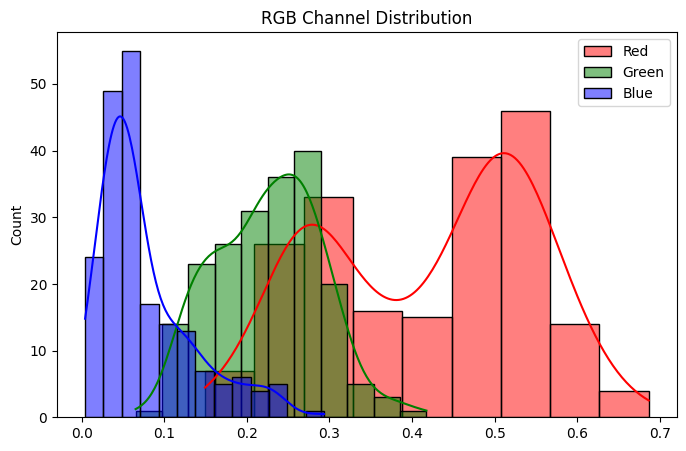

In [ ]:
r_vals = []
g_vals = []
b_vals = []

for path in tqdm(sample_paths):

    img = np.array(
        Image.open(path).convert("RGB")
    ) / 255.0

    r_vals.append(img[:,:,0].mean())
    g_vals.append(img[:,:,1].mean())
    b_vals.append(img[:,:,2].mean())

print("\nRGB Channel Mean")
print("Red   :", np.mean(r_vals))
print("Green :", np.mean(g_vals))
print("Blue  :", np.mean(b_vals))

plt.figure(figsize=(8,5))

sns.histplot(r_vals, color="red", label="Red", kde=True)
sns.histplot(g_vals, color="green", label="Green", kde=True)
sns.histplot(b_vals, color="blue", label="Blue", kde=True)

plt.legend()
plt.title("RGB Channel Distribution")
plt.show()


100%|██████████| 200/200 [00:00<00:00, 1512.01it/s]



Average Brightness: 0.26642181638280316


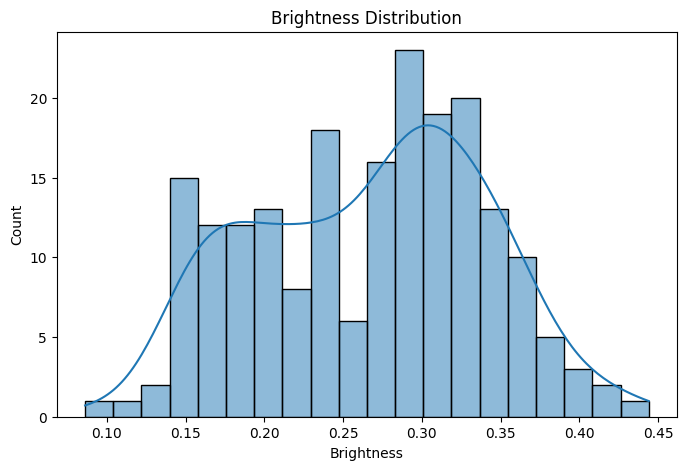

In [ ]:
brightness = []

for path in tqdm(sample_paths):

    img = Image.open(path).convert("L")
    img = np.array(img) / 255.0

    brightness.append(img.mean())

print("\nAverage Brightness:", np.mean(brightness))

plt.figure(figsize=(8,5))
sns.histplot(brightness, bins=20, kde=True)
plt.title("Brightness Distribution")
plt.xlabel("Brightness")
plt.show()

In [ ]:
df_sample = df.sample(
    min(100, len(df)),
    random_state=SEED
).copy()

bright_vals = []

for path in df_sample["image_path"]:

    img = Image.open(path).convert("L")
    img = np.array(img) / 255.0
    bright_vals.append(img.mean())

df_sample["brightness"] = bright_vals

dark_imgs = df_sample.nsmallest(3, "brightness")
bright_imgs = df_sample.nlargest(3, "brightness")

print("\nDarkest Images:")
print(dark_imgs[["image_path","brightness"]])

print("\nBrightest Images:")
print(bright_imgs[["image_path","brightness"]])



Darkest Images:
                                             image_path  brightness
929   /content/data/DR/5548a7961a3e_png.rf.7c8627c76...    0.113264
1572  /content/data/No_DR/a1e236fbc863_png.rf.4951fb...    0.144264
1748  /content/data/No_DR/70d0392397de_png.rf.2e868f...    0.147347

Brightest Images:
                                            image_path  brightness
495  /content/data/DR/63c3c571b8ee_png.rf.16a469817...    0.421905
402  /content/data/DR/00e4ddff966a_png.rf.8e3ea3cd2...    0.421879
748  /content/data/DR/9d9bfefa809c_png.rf.e35aa7d43...    0.407755
